Classification Task

This section presents a classification workflow using a structured road traffic accident dataset. The aim is to predict accident severity from a set of input features.

The notebook demonstrates a complete machine learning pipeline including:
- data loading and inspection,
- exploratory data analysis,
- preprocessing for numerical and categorical variables,
- model training,
- hyperparameter tuning with GridSearchCV,
- and evaluation using appropriate classification metrics.



In [9]:
# ==============================
# Part 1: Imports and Data Loading
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Load dataset
df = pd.read_csv("fars.csv")

print("Dataset shape (rows, columns):", df.shape)
display(df.head())


Dataset shape (rows, columns): (100968, 30)


,CASE_STATE,AGE,SEX,PERSON_TYPE,SEATING_POSITION,RESTRAINT_SYSTEM-USE,AIR_BAG_AVAILABILITY/DEPLOYMENT,EJECTION,EJECTION_PATH,EXTRICATION,...,DRUG_TEST_RESULTS_(2_of_3),DRUG_TEST_TYPE_(3_of_3),DRUG_TEST_RESULTS_(3_of_3),HISPANIC_ORIGIN,TAKEN_TO_HOSPITAL,RELATED_FACTOR_(1)-PERSON_LEVEL,RELATED_FACTOR_(2)-PERSON_LEVEL,RELATED_FACTOR_(3)-PERSON_LEVEL,RACE,INJURY_SEVERITY
0,Alabama,34,Male,Driver,Front_Seat_-_Left_Side_(Drivers_Side),None_Used/Not_Applicable,Air_Bag_Available_but_Not_Deployed_for_this_Seat,Totally_Ejected,Unknown,Not_Extricated,...,0,Not_Tested_for_Drugs,0,Non-Hispanic,No,Not_Applicable_-_Driver/None_-_All_Other_Persons,Not_Applicable_-_Driver/None_-_All_Other_Persons,Not_Applicable_-_Driver/None_-_All_Other_Persons,White,Fatal_Injury
1,Alabama,20,Male,Driver,Front_Seat_-_Left_Side_(Drivers_Side),None_Used/Not_Applicable,Deployed_Air_Bag_from_Front,Totally_Ejected,Unknown,Not_Extricated,...,0,Not_Tested_for_Drugs,0,Non-Hispanic,No,Not_Applicable_-_Driver/None_-_All_Other_Persons,Not_Applicable_-_Driver/None_-_All_Other_Persons,Not_Applicable_-_Driver/None_-_All_Other_Persons,White,Fatal_Injury
2,Alabama,43,Male,Driver,Front_Seat_-_Left_Side_(Drivers_Side),Lap_and_Shoulder_Belt,Air_Bag_Not_Available_for_this_Seat,Not_Ejected,Not_Ejected/Not_Applicable,Extricated,...,0,Not_Tested_for_Drugs,0,Non-Hispanic,No,Not_Applicable_-_Driver/None_-_All_Other_Persons,Not_Applicable_-_Driver/None_-_All_Other_Persons,Not_Applicable_-_Driver/None_-_All_Other_Persons,Black,Fatal_Injury
3,Alabama,38,Female,Passenger_of_a_Motor_Vehicle_in_Transport,Front_Seat_-_Right_Side,Lap_and_Shoulder_Belt,Air_Bag_Not_Available_for_this_Seat,Not_Ejected,Not_Ejected/Not_Applicable,Extricated,...,0,Not_Tested_for_Drugs,0,Not_a_Fatality_(Not_Applicable),Yes,Not_Applicable_-_Driver/None_-_All_Other_Persons,Not_Applicable_-_Driver/None_-_All_Other_Persons,Not_Applicable_-_Driver/None_-_All_Other_Persons,Not_a_Fatality_(Not_Applicable),Incapaciting_Injury
4,Alabama,50,Male,Driver,Front_Seat_-_Left_Side_(Drivers_Side),Lap_and_Shoulder_Belt,Deployed_Air_Bag_from_Front,Not_Ejected,Not_Ejected/Not_Applicable,Not_Extricated,...,0,Not_Tested_for_Drugs,0,Non-Hispanic,Yes,Not_Applicable_-_Driver/None_-_All_Other_Persons,Not_Applicable_-_Driver/None_-_All_Other_Persons,Not_Applicable_-_Driver/None_-_All_Other_Persons,Black,Fatal_Injury


The dataset was loaded correctly and has many samples. It also has numerical and categorical features, so preprocessing is needed before training the model.

Target distribution:
INJURY_SEVERITY
Fatal_Injury                      42116
No_Injury                         20007
Incapaciting_Injury               15072
Nonincapaciting_Evident_Injury    13890
Possible_Injury                    8674
Unknown                             901
Injured_Severity_Unknown            299
Died_Prior_to_Accident                9
Name: count, dtype: int64

Missing values per column:
CASE_STATE                             0
AGE                                    0
SEX                                    0
PERSON_TYPE                            0
SEATING_POSITION                       0
RESTRAINT_SYSTEM-USE                   0
AIR_BAG_AVAILABILITY/DEPLOYMENT        0
EJECTION                               0
EJECTION_PATH                          0
EXTRICATION                            0
NON_MOTORIST_LOCATION                  0
POLICE_REPORTED_ALCOHOL_INVOLVEMENT    0
METHOD_ALCOHOL_DETERMINATION           0
ALCOHOL_TEST_TYPE                      0
ALCOHOL_TEST_RE

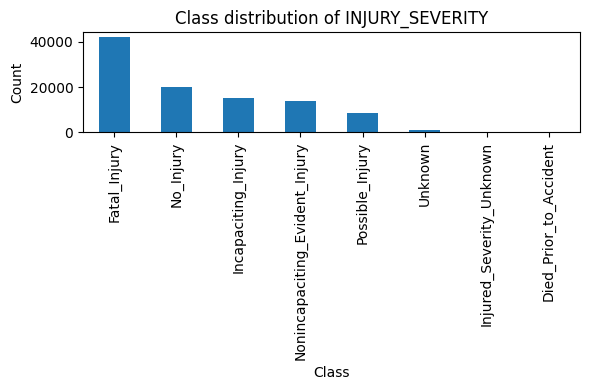

In [10]:
# ==============================
# Part 2: Target definition and EDA
# ==============================
target_col = "INJURY_SEVERITY"
X = df.drop(columns=[target_col])
y = df[target_col]

print("Target distribution:")
print(y.value_counts())

print("\nMissing values per column:")
print(df.isnull().sum())

plt.figure(figsize=(6, 4))
y.value_counts().plot(kind="bar")
plt.title("Class distribution of INJURY_SEVERITY")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


The class distribution is clearly imbalanced. Some classes have many samples, while others have only a few. Because of this, macro F1 is more suitable than accuracy, since it gives balanced attention to all classes.

In [11]:
# ==============================
# Part 3: Data preprocessing
# ==============================
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(exclude=["int64", "float64"]).columns

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


No missing values were found in this dataset. However, preprocessing is still important. The data contains both numerical and categorical features, so different preprocessing steps are needed for different feature types.

In [12]:
# ==============================
# Part 4: Train-test split
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train set size:", X_train.shape)
print("Test set size :", X_test.shape)


Train set size: (80774, 29)
Test set size : (20194, 29)


An 80/20 split was used for training and testing. This gives the model enough data to learn, while still keeping a separate test set for evaluation.

In [13]:
# ==============================
# Part 5: Pipeline 1 - Logistic Regression
# ==============================
pipe_lr = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

param_grid_lr = {
    "classifier__C": [0.1, 1.0, 10.0],
    "classifier__class_weight": [None, "balanced"]
}

grid_lr = GridSearchCV(
    pipe_lr,
    param_grid=param_grid_lr,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)

y_pred_lr = grid_lr.predict(X_test)

print("Best parameters:", grid_lr.best_params_)
print(classification_report(y_test, y_pred_lr))


Best parameters: {'classifier__C': 10.0, 'classifier__class_weight': None}
                                precision    recall  f1-score   support

        Died_Prior_to_Accident       0.00      0.00      0.00         2
                  Fatal_Injury       1.00      1.00      1.00      8423
           Incapaciting_Injury       0.61      0.63      0.62      3014
      Injured_Severity_Unknown       0.57      0.43      0.49        60
                     No_Injury       0.86      0.98      0.92      4002
Nonincapaciting_Evident_Injury       0.47      0.57      0.51      2778
               Possible_Injury       0.48      0.13      0.20      1735
                       Unknown       0.74      0.73      0.73       180

                      accuracy                           0.80     20194
                     macro avg       0.59      0.56      0.56     20194
                  weighted avg       0.79      0.80      0.79     20194



d:\Python\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Python\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\Python\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [14]:
# ==============================
# Part 6: Pipeline 2 - Random Forest
# ==============================
pipe_rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        max_depth=20,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

rf_cv_scores = cross_val_score(
    pipe_rf,
    X_train, y_train,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1
)

pipe_rf.fit(X_train, y_train)
y_pred_rf = pipe_rf.predict(X_test)

print("Random Forest CV f1_macro:", rf_cv_scores.mean())
print(classification_report(y_test, y_pred_rf))


Random Forest CV f1_macro: 0.5559326724453338
                                precision    recall  f1-score   support

        Died_Prior_to_Accident       0.00      0.00      0.00         2
                  Fatal_Injury       1.00      1.00      1.00      8423
           Incapaciting_Injury       0.62      0.57      0.60      3014
      Injured_Severity_Unknown       0.43      0.60      0.50        60
                     No_Injury       0.86      0.98      0.91      4002
Nonincapaciting_Evident_Injury       0.47      0.58      0.52      2778
               Possible_Injury       0.45      0.17      0.25      1735
                       Unknown       0.63      0.82      0.71       180

                      accuracy                           0.80     20194
                     macro avg       0.56      0.59      0.56     20194
                  weighted avg       0.79      0.80      0.79     20194



The random forest model achieved an f1_macro score of about 0.56. This shows moderate overall performance. The model performed better on the larger classes, but performance on the smaller classes was still limited.

In [15]:
# ==============================
# Part 7: Model comparison
# ==============================
print("Logistic Regression f1_macro:", grid_lr.best_score_)
print("Random Forest f1_macro:", rf_cv_scores.mean())


Logistic Regression f1_macro: 0.5480914617280477
Random Forest f1_macro: 0.5559326724453338


Overall, random forest performed slightly better than logistic regression, but the difference was small. This suggests that the more flexible model captured some extra patterns in the data, although class imbalance still affected the results.

Regression Task

This section presents regression experiments for predicting two target variables using structured numerical features.

The workflow includes:
- data inspection,
- exploratory data analysis,
- careful train/validation/test splitting,
- prevention of target leakage,
- model training and hyperparameter tuning,
- and evaluation using regression metrics such as MSE and R².


In [2]:
# Import core libraries
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Import scikit-learn utilities
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.svm import SVR

# Set random seed for reproducibility
RANDOM_STATE = 42


The required Python libraries were imported, and a fixed random seed was used to make the results more reproducible.

In [3]:
# Load the dataset
df = pd.read_csv("fitting-results2.csv")

# Preview the dataset
print("Data Loaded:")
display(df.head())

# Check data types and structure
print("\nBasic Information:")
print(df.info())

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

# Summary statistics
print("\nStatistical Summary:")
display(df.describe())


Data Loaded:


,n_cyanos,co2,light,SucRatio,Nsample,a,mu
0,262,73.578860,0.367894,0.451505,13123,5.033993,5.483011
1,610,74.582194,0.481606,0.969900,12474,1.018406,1.830727
2,118,33.111037,0.625418,0.909699,8867,2.569159,3.330662
3,159,8.027676,0.575251,0.137124,16494,1.837341,3.371570
4,957,38.796599,0.939799,0.234114,10267,0.999268,2.059303



Basic Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19992 entries, 0 to 19991
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   n_cyanos  19992 non-null  int64  
 1   co2       19992 non-null  float64
 2   light     19992 non-null  float64
 3   SucRatio  19992 non-null  float64
 4   Nsample   19992 non-null  int64  
 5   a         19992 non-null  float64
 6   mu        19992 non-null  float64
dtypes: float64(5), int64(2)
memory usage: 1.1 MB
None

Missing values:
n_cyanos    0
co2         0
light       0
SucRatio    0
Nsample     0
a           0
mu          0
dtype: int64

Statistical Summary:


,n_cyanos,co2,light,SucRatio,Nsample,a,mu
count,19992.000000,19992.000000,19992.000000,19992.000000,19992.000000,19992.000000,19992.000000
mean,494.367547,49.890457,0.495162,0.496075,9997.371349,5.490172,5.634110
std,288.957886,29.138328,0.289767,0.289731,5772.058433,13.441047,9.862259
min,2.000000,0.001000,0.000001,0.000000,1.000000,0.000004,0.000539
25%,242.000000,24.415472,0.234114,0.240803,4998.750000,0.703064,1.852808
50%,499.000000,49.833278,0.494984,0.494983,9997.500000,1.775632,3.037436
75%,740.000000,75.251084,0.742475,0.742475,14995.250000,4.210368,5.038206
max,1000.000000,100.000000,1.000000,1.000000,19995.000000,162.186465,123.376876


The dataset was loaded correctly. Basic checks such as head(), info(), missing value counts, and descriptive statistics were used to understand the structure and quality of the data.

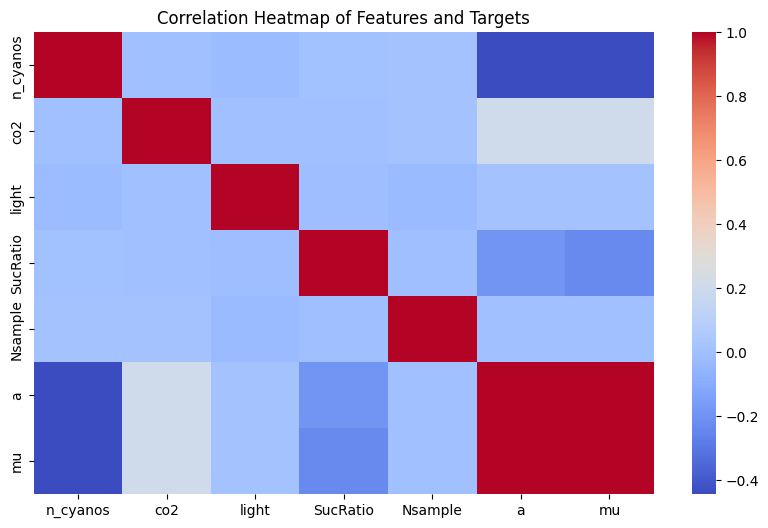

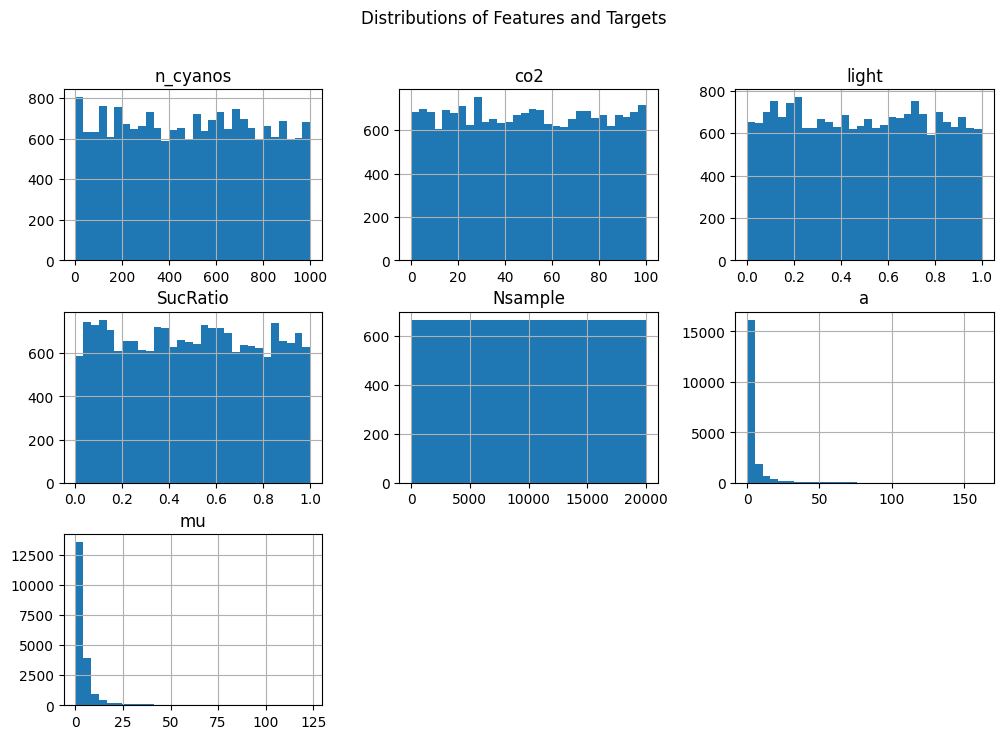

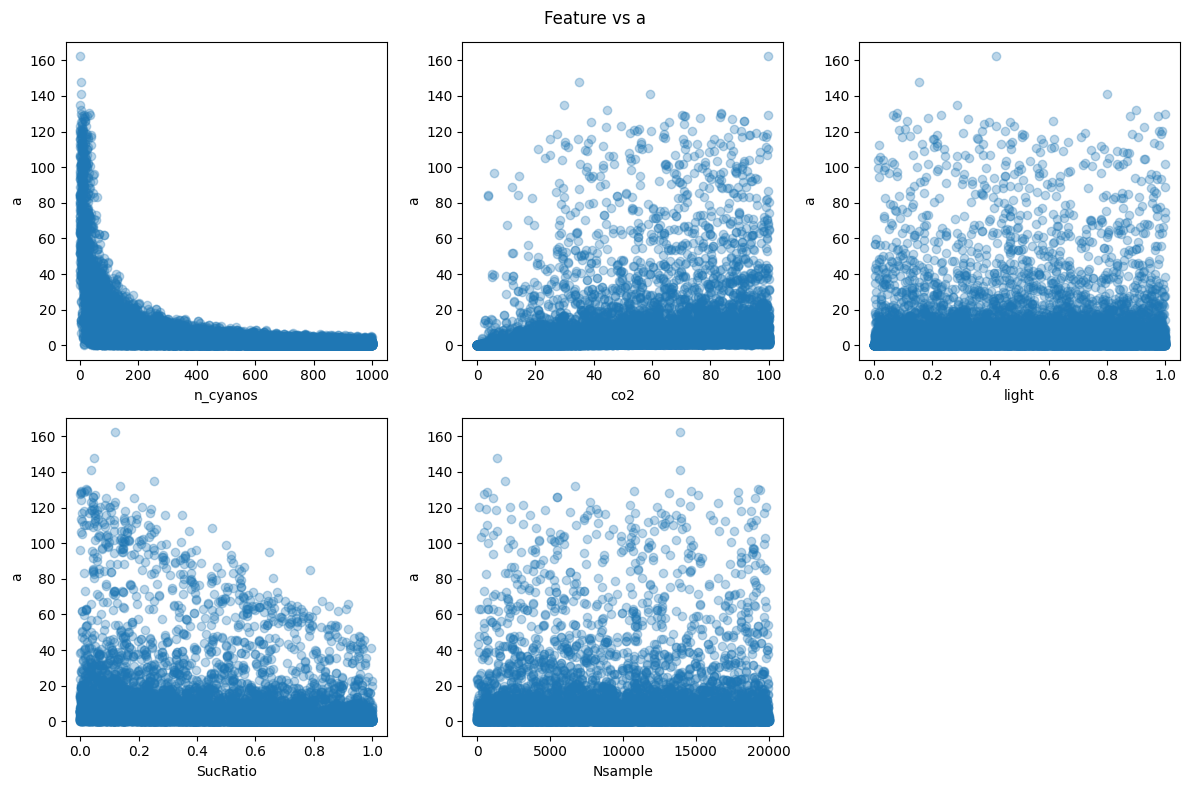

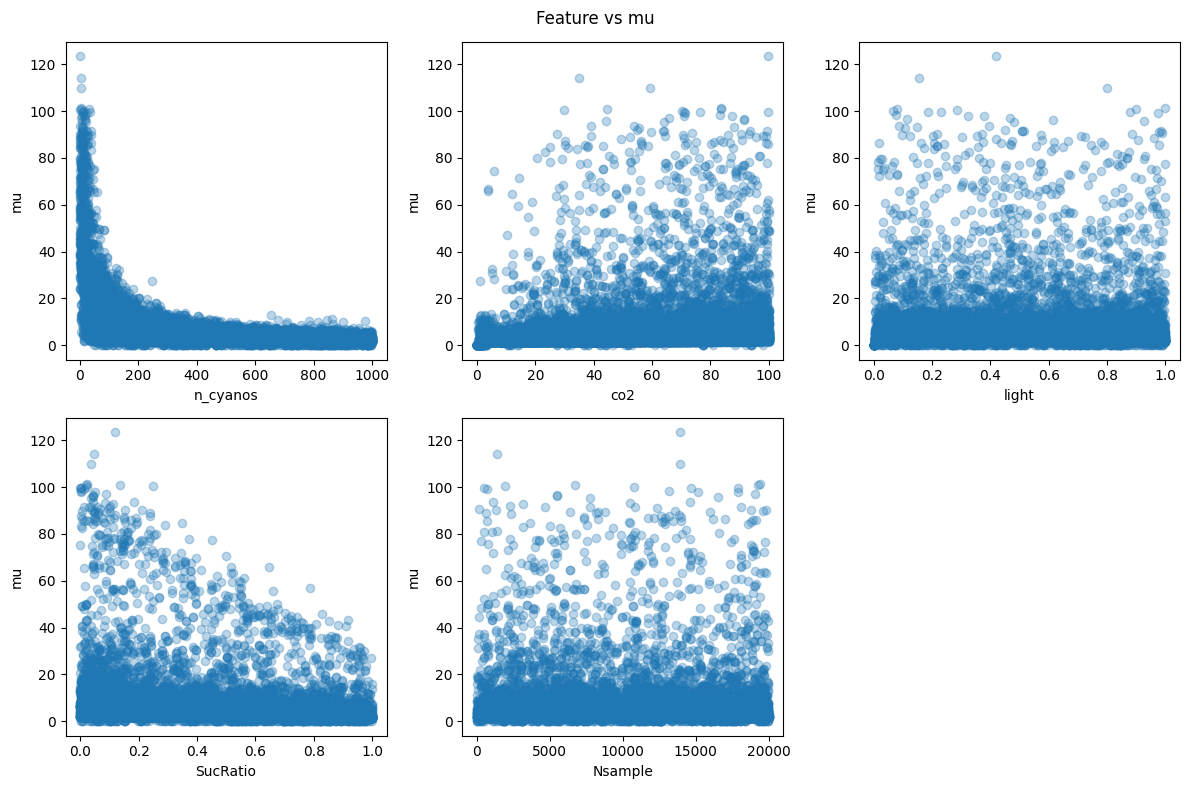

In [4]:
# Correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Correlation Heatmap of Features and Targets")
plt.show()

# Histograms for all variables
df.hist(figsize=(12, 8), bins=30)
plt.suptitle("Distributions of Features and Targets")
plt.show()

# Scatter plots: features vs targets
features = ["n_cyanos", "co2", "light", "SucRatio", "Nsample"]

plt.figure(figsize=(12, 8))
for i, f in enumerate(features):
    plt.subplot(2, 3, i + 1)
    plt.scatter(df[f], df["a"], alpha=0.3)
    plt.xlabel(f)
    plt.ylabel("a")
plt.suptitle("Feature vs a")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
for i, f in enumerate(features):
    plt.subplot(2, 3, i + 1)
    plt.scatter(df[f], df["mu"], alpha=0.3)
    plt.xlabel(f)
    plt.ylabel("mu")
plt.suptitle("Feature vs mu")
plt.tight_layout()
plt.show()


The plots suggest that some relationships in the data are not purely linear. Because of this, it is useful to test non-linear models such as random forest as well as simpler baseline models.

In [5]:
# Select input features
features = ["n_cyanos", "co2", "light", "SucRatio", "Nsample"]
X = df[features]

# Define targets
y_a = df["a"]
y_mu = df["mu"]

# Split data for target a
X_train, X_temp, y_a_train, y_a_temp = train_test_split(
    X, y_a, test_size=0.3, random_state=RANDOM_STATE
)
X_val, X_test, y_a_val, y_a_test = train_test_split(
    X_temp, y_a_temp, test_size=0.5, random_state=RANDOM_STATE
)

# Split data for target mu (same X, different y)
_, _, y_mu_train, y_mu_temp = train_test_split(
    X, y_mu, test_size=0.3, random_state=RANDOM_STATE
)
_, _, y_mu_val, y_mu_test = train_test_split(
    X_temp, y_mu_temp, test_size=0.5, random_state=RANDOM_STATE
)

print("Data split completed.")


Data split completed.


When predicting one target, the other target was removed from the input features. This avoids target leakage and makes the evaluation more reliable.

In [6]:
def evaluate(model, X_eval, y_eval, label):
    """Evaluate a regression model using MSE and R²."""
    predictions = model.predict(X_eval)
    mse = mean_squared_error(y_eval, predictions)
    r2 = r2_score(y_eval, predictions)
    print(f"\n{label}")
    print("MSE:", mse)
    print("R²:", r2)
    return mse, r2


def run_grid(name, grid, X_tr, y_tr, X_val, y_val):
    """Train GridSearchCV model, record time, and evaluate."""
    print(f"\nTraining {name}")
    start = time.time()
    grid.fit(X_tr, y_tr)
    end = time.time()
    print(f"{name} finished in {end - start:.2f} seconds")
    evaluate(grid, X_val, y_val, name)
    return grid


GridSearchCV was used to tune model parameters in a systematic way. The validation set was used to compare models and choose better settings.

In [7]:
# Pipeline A1: Ridge Regression (linear baseline)
pipe_a1 = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge())
])

param_a1 = {
    "ridge__alpha": [0.1, 1, 10, 50]
}

grid_a1 = GridSearchCV(
    pipe_a1, param_a1, cv=3, n_jobs=-1, verbose=1
)

grid_a1 = run_grid(
    "A1 Ridge Regression", grid_a1,
    X_train, y_a_train, X_val, y_a_val
)

# Pipeline A2: Random Forest (non-linear model)
pipe_a2 = Pipeline([
    ("rf", RandomForestRegressor(random_state=RANDOM_STATE))
])

param_a2 = {
    "rf__n_estimators": [100, 200],
    "rf__max_depth": [5, 10, None]
}

grid_a2 = GridSearchCV(
    pipe_a2, param_a2, cv=3, n_jobs=-1, verbose=1
)

grid_a2 = run_grid(
    "A2 Random Forest", grid_a2,
    X_train, y_a_train, X_val, y_a_val
)



Training A1 Ridge Regression
Fitting 3 folds for each of 4 candidates, totalling 12 fits
A1 Ridge Regression finished in 16.83 seconds

A1 Ridge Regression
MSE: 129.30482259348648
R²: 0.2826804112390152

Training A2 Random Forest
Fitting 3 folds for each of 6 candidates, totalling 18 fits
A2 Random Forest finished in 64.10 seconds

A2 Random Forest
MSE: 6.361672345907246
R²: 0.9647085692592862


MSE and R² were used as the main evaluation metrics. In these experiments, the random forest model achieved the best performance for predicting both mu and a.

In [8]:
RUN_MU_MODELS = True  # Set to False to skip retraining

if RUN_MU_MODELS:
    # Pipeline M1: SVR
    pipe_m1 = Pipeline([
        ("scaler", StandardScaler()),
        ("svr", SVR())
    ])

    param_m1 = {
        "svr__C": [0.1, 1, 10],
        "svr__gamma": ["scale", "auto"]
    }

    grid_m1 = GridSearchCV(
        pipe_m1, param_m1, cv=3, n_jobs=-1, verbose=1
    )

    grid_m1 = run_grid(
        "M1 SVR", grid_m1,
        X_train, y_mu_train, X_val, y_mu_val
    )

    # Pipeline M2: Random Forest
    pipe_m2 = Pipeline([
        ("rf", RandomForestRegressor(random_state=RANDOM_STATE))
    ])

    param_m2 = {
        "rf__n_estimators": [100, 200],
        "rf__max_depth": [5, 10, None]
    }

    grid_m2 = GridSearchCV(
        pipe_m2, param_m2, cv=3, n_jobs=-1, verbose=1
    )

    grid_m2 = run_grid(
        "M2 Random Forest", grid_m2,
        X_train, y_mu_train, X_val, y_mu_val
    )

print("ALL DONE")



Training M1 SVR
Fitting 3 folds for each of 6 candidates, totalling 18 fits
M1 SVR finished in 107.59 seconds

M1 SVR
MSE: 37.7585467608023
R²: 0.6084381741117972

Training M2 Random Forest
Fitting 3 folds for each of 6 candidates, totalling 18 fits
M2 Random Forest finished in 40.25 seconds

M2 Random Forest
MSE: 3.7534567967410752
R²: 0.9610760867987073
ALL DONE


Overall, random forest gave the best results for predicting both target variables. A possible reason is that it can capture more complex non-linear patterns in the data.